
La regresión logística es un modelo estadístico utilizado para modelar la $probabilidad $ de ocurrencia de un evento en función de una o más variables independientes. Aunque su nombre incluye la palabra "regresión", la regresión logística se utiliza comúnmente para problemas de clasificación binaria, donde el resultado deseado es una variable categórica con dos categorías (por ejemplo, sí/no, éxito/fracaso, positivo/negativo).

Para este modelo existen 3 tipos de regresión:

- Binaria: La variable objetivo tiene solo 2 posibles resultados
- Multinomial: La variable objetivo tiene mas de 2 posibles resultados
- Ordinal :La variable objetivo tiene tres o más categorías ordinales (Ejmplo: Calificar del 1 al 5 un servicio )


¿Qué ejemplos de problemas podriamos resolver ?
* Riesgo de Crédito: Prestar o no prestar dinero
* Probabilidad de concretar una venta o no
* Probabilidad de que suba o baje el precio de una acción
* Probabilidad de Fraude o no
* Si un cliente va a cancelar un producto
* Evento Deportivo: Ganar o perder
* Probabilidad de Bancarrota
* Si sube o no la tasa banxico. 
* Probabilidad de renuncia  de una persona
* etc


El modelo  trata de ajustar un hiperplano a los datos $(x, y)$ donde $y = 1$, si las caracteristicas de las variables pertenecen a la 
clase; y $y = 0$, si las caracteristicas de las variables  no pertenecen a la clase. 

Debido a que la variable $y$ es booleana, no es conveniente ajustar el hiperplano directamente, ya que 
el hiperplano tiene un rango de -∞ a +∞.

Con el fin de que el rango de probabilidad [0, 1] cubra el rango de un hiperplano, se hacen dos cosas:

Se estima el índice de probabilidades (odds ratio), en lugar de la probabilidad $ P(Y=1|X) $ la cual tiene un rango de [0,1], para transformar el rango a [0,∞)

$$
odds = \frac{P(Y=1|X)}{1-P(Y=1|X)}
$$

Posteriromente aplicamos logaritmo a la anterior funcion para transformar al rango (-∞,∞) para obtener la llamada funcion "logit"

$$
logit(P(X)) = ln(\frac{P(Y=1|X)}{1-P(Y=1|X)}) = \beta_{0} + \beta_{1}x_1 +...+ \beta_{n}x_n= z
$$


aplicando la función exponencial tenemos lo siguiente

$$
\frac{P(Y=1|X)}{1-P(Y=1|X)} = e^z
$$

despejando y manipulando la anterior funcion llegamos a lo siguiente

<img src="demostracionlogistica.png">

recordemos que $z$ es el plano $z=\beta_{0} + \beta_{1}x_1 +...+ \beta_{n}x_n$

la anterior funcion se ve como sigue


<img src="funcionsigmoide.png">

de esta forma $y=1$ si $f(x)>=.5$ y  $y=0$ si $f(x)<.5$

La regresión logística no se basa en supuestos distribucionales . Sin embargo, la solución puede ser más estable si los predictores tienen una distribución normal multivariante. Adicionalmente, al igual que con otras formas de regresión, la multicolinealidad entre los predictores puede llevar a estimaciones sesgadas y a errores estándar inflados. La regresión logística es un algoritmo lineal, con una transformación no lineal en la salida


### ¿Cómo estimamos los coeficientes en regresión logistica?

En lugar de minimizar una función de error como en la regresión lineal, en la regresión logística se maximiza la función de verosimilitud. La función de verosimilitud representa la probabilidad conjunta de observar los datos dados los parámetros del modelo.

En la regresión logística, suponemos que los datos son generados por un proceso de Bernoulli, que modela la probabilidad de pertenecer a la categoría 1 (éxito) frente a la probabilidad de pertenecer a la categoría 0 (fracaso). La función de verosimilitud se define como el producto de las probabilidades de observar las respuestas dadas las variables predictoras y los parámetros del modelo.

si tenemos un conjunto de observaciones donde $ (y_1,x_1),...,(y_n,x_n) $ donde $ y_i$ es la variable de respuesta (0,1) para la obervacion $i$ y $x_i$ es el vector de variables predictoras asociadas, la función de verosimilitud (L) se define como:


$$L(\beta)=\prod_{i=1}^n P(y_i|x_i,\beta)$$


Donde  $ P(y_i|x_i,\beta) $ es la función de probabilidad de observar $y_i$ dadas las variables $x_i$ y los coeficientes $ \beta $

Para la regresión logística, esta probabilidad se expresa mediante la función logística (o sigmoide):

$ P(y_i=1 \mid x_i, \beta) = \frac{1}{1 + e^{-(\beta_0 + \beta_1x_{i1} + \beta_2x_{i2} + \ldots + \beta_px_{ip})}} $

$ P(y_i=0 \mid x_i, \beta) = 1 - P(y_i=1 \mid x_i, \beta) $

El objetivo es maximizar $ log(L(\beta))$ , ya que maximizar el logaritmo de la verosimilitud simplifica los cálculos. Esto se conoce como la función de log-verosimilitud.

$ L(\beta) = \sum_{i=1}^{n} \left[ y_i \log(P(y_i=1 \mid x_i, \beta)) + (1-y_i) \log(1 - P(y_i=1 \mid x_i, \beta)) \right]  $


No existe una formula cerrada para encontrar los parámetros óptimos de una regresión logística, por lo que recurrimos a descenso de gradiente para minimizar: $L(\beta)$

##### VENTAJAS:
- Facil entendimiento e interpretación
- Se puede utilizar regularización
- Entrenamiento rapido
    
##### DESVENTAJAS: 
- Problemas para ajustar en datos no lineales
- Sensible a datos atipicos
- Sencillo para captar relaciones complejas

### ANALISIS DE ERRORES

Así como en los modelos de regresión definimos algunos criterios de evaluación debemos hacer lo mismo en los modelos de clasificación. Podemos empezar a desarrollar el analisis de errores definiendo la matriz de confusión que se denota como sigue:

<img src="confusionmatrix.png">

Verdadero positivo (TP): El valor real es positivo y  el modelo predijo tambien que era positivo.

Verdadero negativo (TN): El valor real  es negativo y el modelo predijo tambien que el resultado era negativo.

Falso negativo (FN): El valor real es positivo, y el modelo predijo  que el resultado es negativo. Esto es lo que en estadística se conoce como error tipo II

Falso positivo (FP): El valor real es negativo, y el modelo predijo  que el resultado es positivo. Esto es lo que en estadística se conoce como error tipo I

Con la anterior matriz podemos definir las siguientes metricas

1. De todos los que dijimos que son positivos (denomidador), cuáles sí son positivos (numerador). "porcentaje de casos positivos detectados" es útil cuando el costo de los falsos positivos es alto.

$$
    \mbox{Precision} = \frac{TP}{TP + FP}
$$

2. De todos los unos verdaderos  que hay en la base (denominador), cuále sí dijimos que son unos (numerador). Dicho de otra forma, *Recall* considera todos los valores que sí son realmente positivos. (Fraccion de verdaderos positivos) (En medicina capacidad de de poder detectar correctamente la enfermedad entre los enfermos) es útil cuando el costo de los falsos negativos es alto.

$$
    \mbox{Recall/Sensitivity} = \frac{TP}{TP + FN}
$$



3. También conocida como la Tasa de Verdaderos Negativos, (“true negative rate”) o TN. Se trata de los casos negativos que el algoritmo ha clasificado correctamente.  Expresa cuan bien puede el modelo detectar esa clase. (Fraccion de verdaderos negativos) (1 -Especificidad = tasa de falsos positivos)

$$
    \mbox{Especificity} = \frac{TN}{TN + FP}
$$

4. De todas las observaciones (denominador), cuáles predicciones son correctas (tanto unos y ceros) (numerador) "cantidad de predicciones correctas"

$$
    \mbox{Accuracy} = \frac{TP+TN}{TP + FN + FP+TN}
$$


5. Surge para Intentar Resolver el Trade-off entre Precision y sensitivity. Es una puntuación unica que representa ambas metricas (Promedio ponderado de precision y sensitivity) buscamos que el valor sea cercano a 1.

$$
    \mbox{F1_Score} = \frac{2 * Precision * Sensitivity}{Precision + Sensitivity}
$$

Cuando tenemos un conjunto de datos balanceados (aproximadamente 50% de los registros con la clase 1 y 50% con la clase 0) el accuracy es la metrica por defecto para evaluar al modelo (así como el r2 en regresión)

con las anteriores definiciones podemos ver las metricas en la matriz de confusión

<img src="confusion_matrix2.png">

6. La curva ROC (Receiver Operating Characteristic) y el área bajo la curva (AUC, del inglés Area Under the Curve) son dos herramientas adicionales utilizadas en la evaluación del rendimiento de modelos de clasificación

###### Curva ROC:

La curva ROC es un gráfico que representa la tasa de verdaderos positivos (sensibilidad) en el eje y y la tasa de falsos positivos (1 - especificidad) en el eje x. Cada punto en la curva corresponde a un umbral de clasificación diferente.
Un modelo perfecto tendría una curva ROC que se acercaría rápidamente al punto (0, 1), es decir, con una sensibilidad del 100% y una especificidad del 100%. En la práctica, la curva ROC ayuda a visualizar cómo varía el rendimiento del modelo a medida que se ajusta el umbral de clasificación.
Área bajo la curva (AUC):

##### El AUC (Area bajo la curva)

es una métrica numérica que representa el área bajo la curva ROC. La AUC varía de 0 a 1, donde 0 indica un rendimiento pobre (similar a una clasificación aleatoria) y 1 indica un rendimiento perfecto.
Una AUC de 0.5 sugiere que el modelo es equivalente a una clasificación aleatoria, mientras que un valor superior a 0.5 indica que el modelo tiene un rendimiento mejor que el azar.
Cálculo de la curva ROC y AUC:

Para construir la curva ROC, se requiere calcular la sensibilidad y la especificidad para varios umbrales de clasificación. Luego, se grafican estos puntos.
El AUC se calcula integrando el área bajo la curva ROC. 


<img src="rocauc.png">

In [1]:
import numpy as np
import pandas as pd
import requests
from io import StringIO

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.model_selection import cross_validate
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score,accuracy_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

In [2]:
### CARGAMOS DATASET DE TUMORES
datalink="http://archive.ics.uci.edu/ml/machine-learning-databases/mammographic-masses/mammographic_masses.data"
df=pd.read_csv(StringIO(requests.get(datalink).text),na_values="?",header=None)
df.columns=["bi_rads","age","shape","margin","density","severity"]

documentacion



1. BI-RADS: evaluacion 1 a 5 (ordinal, no predictiva)
2. age: edad del paciente en año (entero)
3. shape: forma: redonda=1 ovalada=2 lobular=3 irregular=4 (nominal)
4. Margin: margen de masa: circunscrito=1 microlobulado=2 oscurecido=3 mal definido=4 espiculado=5 (nominal)
5. Density: densidad de masa alta=1 iso=2 baja=3 que contiene grasa=4 (ordinal)
6. severity:  severidad benigno=0 o maligno=1 (binominal, variable objetivo)

In [13]:
df.bi_rads.unique()

array([ 5.,  4.,  3., nan,  2., 55.,  0.,  6.])

In [14]:
df.shape

(961, 6)

In [15]:
df.head(5)

,bi_rads,age,shape,margin,density,severity
0,5.0,67.0,3.0,5.0,3.0,1
1,4.0,43.0,1.0,1.0,NaN,1
2,5.0,58.0,4.0,5.0,3.0,1
3,4.0,28.0,1.0,1.0,3.0,0
4,5.0,74.0,1.0,5.0,NaN,1


In [16]:
### data set balanceado
print("total malignos ",df[df.severity==1].shape[0])
print("total benignos ",df[df.severity==0].shape[0])

total malignos  445
total benignos  516


In [17]:
df.isnull().sum() ### cantidad de datos faltantes por columna

bi_rads      2
age          5
shape       31
margin      48
density     76
severity     0
dtype: int64

<Axes: >

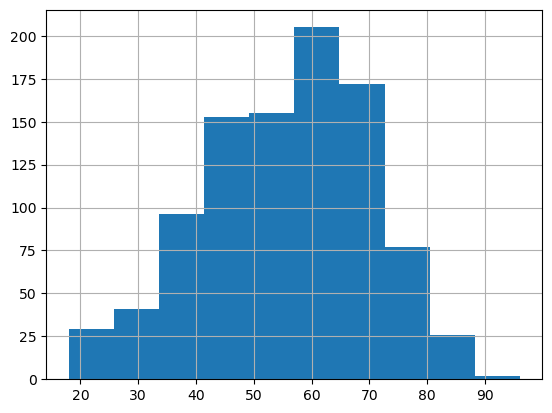

In [18]:
df["age"].hist()

In [19]:
df["age"].describe() ### mediana y media casi iguales. reemplazamos faltantes con media

count    956.000000
mean      55.487448
std       14.480131
min       18.000000
25%       45.000000
50%       57.000000
75%       66.000000
max       96.000000
Name: age, dtype: float64

<Axes: >

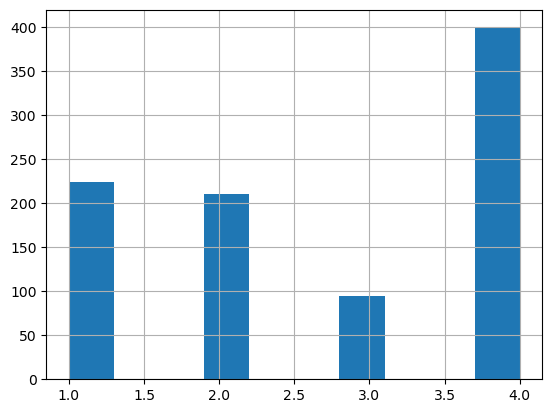

In [20]:
df["shape"].hist() ### este histograma lo interpretamos como un barplot, debido a que los valores son categorias

<Axes: >

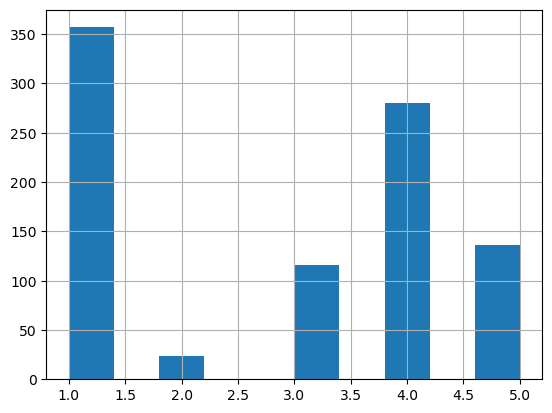

In [21]:
df["margin"].hist() ### este histograma lo interpretamos como un barplot, debido a que los valores son categorias

<Axes: >

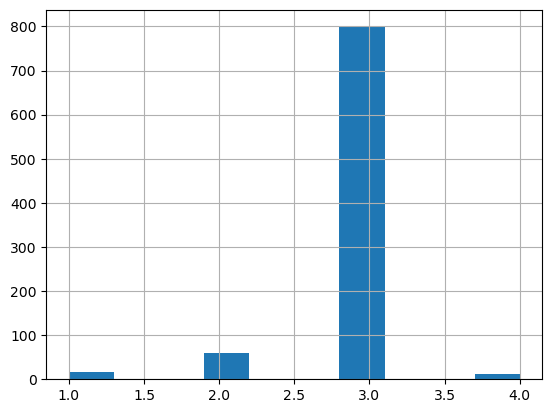

In [22]:
df["density"].hist() ### este histograma lo interpretamos como un barplot, debido a que los valores son categorias

In [23]:
### llenamos NAs con media y modas
df["age"] = df["age"].fillna(df["age"].mean())
df["shape"] = df["shape"].fillna(4)
df["margin"] = df["margin"].fillna(1)
df["density"] = df["density"].fillna(3)


In [24]:
df.isnull().sum() ### limpiamos datos faltantes

bi_rads     2
age         0
shape       0
margin      0
density     0
severity    0
dtype: int64

In [25]:
#df = df[df.bi_rads.isin([55,6])]
#df.shape

#### vemos que a mayor edad hay mas probabilidad de tener un tumor maligno

<Axes: xlabel='age', ylabel='severity'>

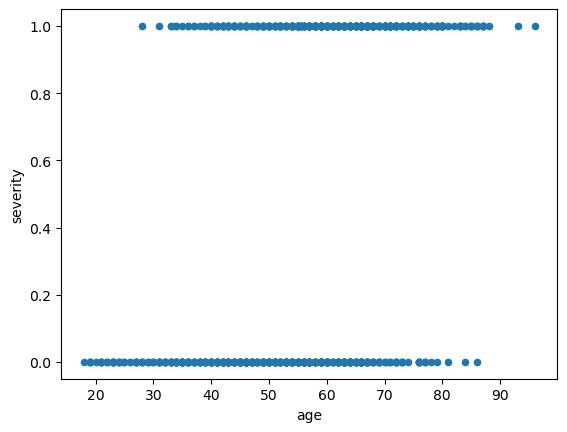

In [33]:

df.plot(x="age",y="severity",kind="scatter")


In [26]:
df = df[["age","severity"]]

In [27]:
train,test=train_test_split(df,test_size=0.2,random_state=0)

In [28]:
x_train = train["age"].values.reshape(-1,1)
y_train = train["severity"]

ajustamos modelo lineal utilizando unicamente la edad

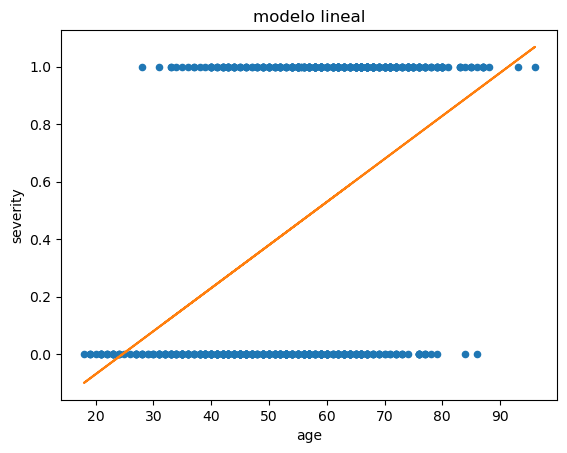

In [37]:
linreg = LinearRegression().fit(x_train,y_train)
train.plot(x="age",y="severity",kind="scatter",title="modelo lineal")
plt.plot(x_train,linreg.predict(x_train),color="tab:orange")

In [38]:
#Cuál será la proa de tener un tumor malingn para una persona de 24 años
linreg.predict([[24]])
# el resultado no tiene sentido

array([-0.01022118])

In [39]:
### necesitamos predicciones en el intervalo [0,1] para esto vamos a definir la función sigmoidal
def sigmoid(x): 
    return (1/(1+np.exp(-x)))

### probamos para distintos valores de x

In [40]:
sigmoid(1000)

1.0

In [41]:
sigmoid(1)

0.7310585786300049

In [42]:
sigmoid(0)

0.5

In [43]:
sigmoid(-100)

3.7200759760208356e-44

de lo anterior vemos que si el numero es muy grande el valor de la función converge en 1, mientras que es muy chico converge a cero

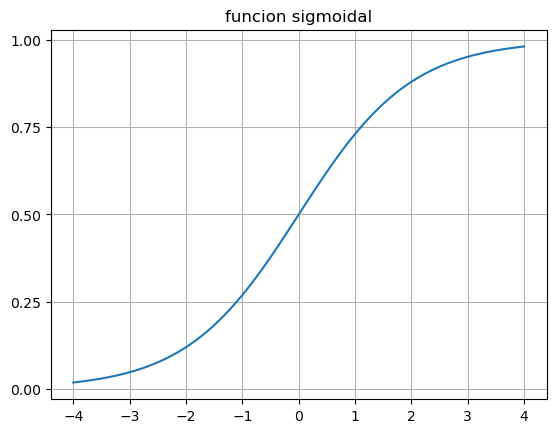

In [44]:
xrange=np.linspace(-4,4,300)
plt.plot(xrange,sigmoid(xrange))
plt.title("funcion sigmoidal")
plt.yticks(np.arange(0,1.1,0.25))
plt.grid()
### graficamos la funcion

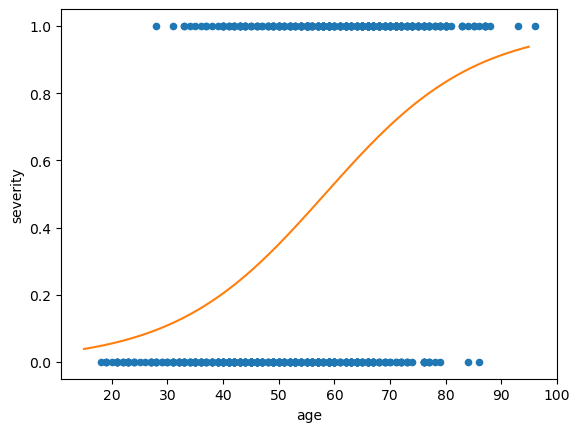

In [29]:
log_reg= LogisticRegression().fit(x_train,y_train)
y_pred = log_reg.predict(x_train)
train.plot(x="age",y="severity",kind="scatter")
xrange=np.arange(15,95,.1)
xrange.reshape(-1,1)
plt.plot(xrange,log_reg.predict_proba(xrange.reshape(-1,1))[:,1],color="tab:orange")

In [48]:
log_reg.predict_proba(xrange.reshape(-1,1)) ### para edades chicas hay mas probabilidad de tener un tomor benigno , para edades grandes hay mas probabilidad de tener un tomor maligno

array([[0.9614695 , 0.0385305 ],
       [0.96119343, 0.03880657],
       [0.96091546, 0.03908454],
       ...,
       [0.06285629, 0.93714371],
       [0.06242024, 0.93757976],
       [0.06198702, 0.93801298]])

In [49]:
log_reg.predict(xrange.reshape(-1,1)) 
### estimando puntualmente la etiqueta vemos que la segunda mitad de edades se clasifica con tumores malignos

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [50]:
#evaluamos el accuracy del modelo 
log_reg.score(x_train,y_train)

0.6796875

In [51]:
### hacemos validación cruzada
cvscore=cross_validate(log_reg,x_train,y_train,cv=5,scoring="accuracy")
cvscore

{'fit_time': array([0.00536919, 0.00516486, 0.00514364, 0.00566983, 0.00614476]),
 'score_time': array([0.00162315, 0.00100183, 0.00100064, 0.00054169, 0.00200176]),
 'test_score': array([0.7012987 , 0.63636364, 0.7012987 , 0.67973856, 0.67973856])}

In [52]:
cvscore["test_score"].mean() ## tenemos un accuracy promedio de aprox 68%

0.679687632628809

### ¿cómo interpretamos los coeficientes?

El significado de un coeficiente de regresión logística no es tan sencillo como el de un coeficiente de regresión lineal. Mientras que $\beta$ es conveniente para probar la utilidad de los predictores, $exp(\beta)$ es más fácil de interpretar. $exp(\beta)$  representa la razón-cambio en las probabilidades del evento de interés para un cambio de una unidad en el predictor. 

In [53]:
print("b1",log_reg.coef_)
print("exp(b1)",np.exp(log_reg.coef_))

b1 [[0.07426598]]
exp(b1) [[1.07709325]]


lo anterior significa que la situación de tener un tumor maligno en una persona de edad n  es de 1.07 veces más riesgosa que para una persona de edad n-1

en otras palabras  Si el β asociado a una covariable X es positivo significa que al aumentar X la probabilidad P(Y=1)(Tener tumor maligno)
se incrementa, eso significa que X favorece la aparición del evento de interés.

### matriz de confusión

[[298 118]
 [128 224]]


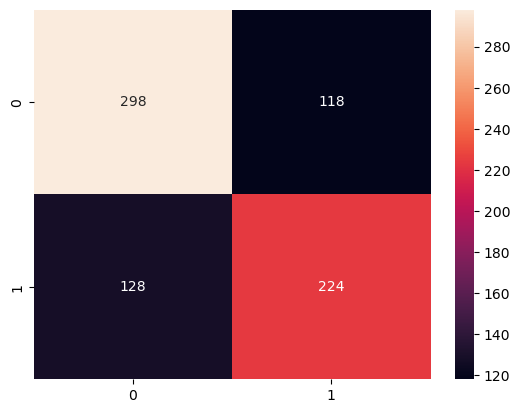

In [54]:
cmat=confusion_matrix(y_train,log_reg.predict(x_train))
sns.heatmap(cmat,annot=True,fmt=",")
### X predicciones, Y reales
print(cmat)

calculo de entradas de matriz de conf de manera manueal y con funciones

In [54]:
TP=cmat[1,1]
TN=cmat[0,0]
FP=cmat[0,1]
FN=cmat[1,0]

In [55]:
accuracy=(TP+TN)/(TP+TN+FN+FP)
precision=(TP)/(TP+FP)
recall=(TP)/(TP+FN)
f1=(TP)/(TP+((FN+FP)/2))


In [56]:
print(f"Accuracy:{accuracy:0.2%}")
print(f"precision:{precision:0.2%}")
print(f"recall:{recall:0.2%}")
print(f"f1:{f1:0.2%}")

Accuracy:67.97%
precision:65.50%
recall:63.64%
f1:64.55%


In [57]:
### calculo utilizando funciones
print(f"Accuracy:{log_reg.score(x_train,y_train):0.2%}")
print(f"precision:{precision_score(y_train,y_pred):0.2%}")
print(f"recall:{recall_score(y_train,y_pred):0.2%}")
print(f"f1:{f1_score(y_train,y_pred):0.2%}")

Accuracy:67.97%
precision:65.50%
recall:63.64%
f1:64.55%


### curva roc

graficamos la curva roc, para esto necesitamos la tasa de falsos positivos, la tasa de verdaderos positivos y los distintos umbrales

In [56]:
fpr,tpr,threshold=roc_curve(y_train,log_reg.predict_proba(x_train)[:,1])

In [60]:
fpr # tasa de falsos positivos

array([0.        , 0.        , 0.        , 0.        , 0.00240385,
       0.00240385, 0.00480769, 0.00480769, 0.00480769, 0.00480769,
       0.00721154, 0.00961538, 0.01682692, 0.03125   , 0.03125   ,
       0.03365385, 0.04086538, 0.05048077, 0.05528846, 0.06009615,
       0.06971154, 0.07932692, 0.09855769, 0.12740385, 0.14182692,
       0.16826923, 0.19471154, 0.21394231, 0.22355769, 0.25      ,
       0.28365385, 0.29807692, 0.33413462, 0.36057692, 0.36057692,
       0.38221154, 0.40144231, 0.44230769, 0.46394231, 0.48317308,
       0.50721154, 0.53605769, 0.54567308, 0.56730769, 0.59855769,
       0.63461538, 0.65625   , 0.68269231, 0.70913462, 0.73557692,
       0.75961538, 0.78125   , 0.79807692, 0.80769231, 0.82451923,
       0.84855769, 0.86057692, 0.87740385, 0.89182692, 0.90625   ,
       0.91346154, 0.91826923, 0.92788462, 0.93990385, 0.94471154,
       0.95192308, 0.96634615, 0.97355769, 0.98798077, 0.99038462,
       0.99759615, 1.        ])

In [61]:
tpr # tasa de verdaderos positivos

array([0.        , 0.00284091, 0.00852273, 0.02272727, 0.02556818,
       0.03409091, 0.03693182, 0.04545455, 0.04829545, 0.07102273,
       0.08522727, 0.09375   , 0.11079545, 0.13352273, 0.15340909,
       0.18181818, 0.19602273, 0.22443182, 0.26136364, 0.28693182,
       0.30681818, 0.34375   , 0.38636364, 0.4375    , 0.47443182,
       0.49715909, 0.52272727, 0.55681818, 0.57954545, 0.59659091,
       0.63636364, 0.67329545, 0.69886364, 0.71590909, 0.72159091,
       0.75284091, 0.77840909, 0.78977273, 0.80965909, 0.82102273,
       0.84090909, 0.85795455, 0.86931818, 0.875     , 0.88636364,
       0.89488636, 0.91193182, 0.92897727, 0.94318182, 0.95170455,
       0.96875   , 0.97159091, 0.97443182, 0.98011364, 0.98295455,
       0.98579545, 0.98863636, 0.99431818, 0.99431818, 0.99715909,
       0.99715909, 0.99715909, 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        ])

In [62]:
threshold # umbrales

array([1.94259641, 0.94259641, 0.90064426, 0.89379807, 0.88653957,
       0.87885222, 0.87071998, 0.86212748, 0.84350499, 0.83344967,
       0.82288391, 0.81179924, 0.80018929, 0.78805012, 0.77538047,
       0.76218203, 0.74845966, 0.73422158, 0.71947965, 0.70424939,
       0.68855019, 0.67240528, 0.65584177, 0.63889055, 0.62158615,
       0.60396655, 0.58607286, 0.56794904, 0.54964147, 0.53119847,
       0.51266985, 0.49410634, 0.47555907, 0.45707897, 0.44764934,
       0.43871626, 0.42051987, 0.40253693, 0.38481233, 0.36738828,
       0.35030392, 0.33359508, 0.317294  , 0.30142918, 0.28602526,
       0.27110303, 0.25667944, 0.24276764, 0.22937717, 0.21651411,
       0.20418126, 0.19237841, 0.18110257, 0.17034824, 0.16010766,
       0.15037113, 0.1411272 , 0.13236301, 0.12406447, 0.11621652,
       0.10880334, 0.10180856, 0.09521541, 0.08900693, 0.0776758 ,
       0.07251932, 0.06768003, 0.06314168, 0.05888844, 0.05490491,
       0.05117619, 0.04768791])

Text(0.5, 1.0, 'ROC CURVE')

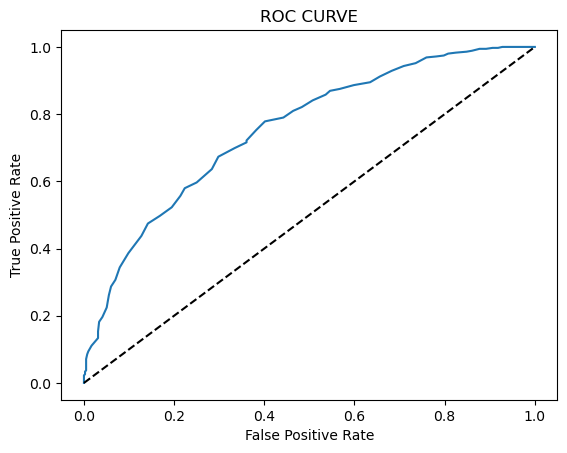

In [63]:

plt.plot(fpr,tpr)
plt.plot(fpr,fpr,linestyle="--",color="k")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC CURVE")

In [65]:
AUROC=roc_auc_score(y_train,log_reg.predict_proba(x_train)[:,1])
AUROC # al tener una area bajo de la curva de .75 tenemos un modelo aceptable

0.7537833260489509

In [67]:
### calculamos el estadistico J de Youden
J=tpr-fpr
J

array([0.        , 0.00284091, 0.00852273, 0.02272727, 0.02316434,
       0.03168706, 0.03212413, 0.04064685, 0.04348776, 0.06621503,
       0.07801573, 0.08413462, 0.09396853, 0.10227273, 0.12215909,
       0.14816434, 0.15515734, 0.17395105, 0.20607517, 0.22683566,
       0.23710664, 0.26442308, 0.28780594, 0.31009615, 0.3326049 ,
       0.32888986, 0.32801573, 0.34287587, 0.35598776, 0.34659091,
       0.35270979, 0.37521853, 0.36472902, 0.35533217, 0.36101399,
       0.37062937, 0.37696678, 0.34746503, 0.34571678, 0.33784965,
       0.33369755, 0.32189685, 0.3236451 , 0.30769231, 0.28780594,
       0.26027098, 0.25568182, 0.24628497, 0.2340472 , 0.21612762,
       0.20913462, 0.19034091, 0.1763549 , 0.17242133, 0.15843531,
       0.13723776, 0.12805944, 0.11691434, 0.10249126, 0.09090909,
       0.08369755, 0.07888986, 0.07211538, 0.06009615, 0.05528846,
       0.04807692, 0.03365385, 0.02644231, 0.01201923, 0.00961538,
       0.00240385, 0.        ])

In [68]:
ix=np.argmax(J)
best_threshold=threshold[ix]
best_threshold # el estadistico nos dice que deberiamos ajustar nuestro umbral en un valor de .42

0.42051986859339346

### trade off precision recall

In [64]:
# calculamos la precision, recall y threshold para distintos umbrales para ver el trade off entre ambas metricas
precision,recall,threshold=precision_recall_curve(y_train,log_reg.predict_proba(x_train)[:,1])

In [65]:
precision

array([0.45833333, 0.4589309 , 0.46073298, 0.46133683, 0.46499339,
       0.4668435 , 0.47058824, 0.47248322, 0.47311828, 0.47375505,
       0.47696477, 0.47885402, 0.48016416, 0.48214286, 0.48543689,
       0.48951049, 0.49291785, 0.49571429, 0.50217707, 0.50660793,
       0.50814815, 0.51274363, 0.51902588, 0.5226209 , 0.52950558,
       0.53518822, 0.54040404, 0.54404145, 0.55614973, 0.56617647,
       0.57410882, 0.5752381 , 0.58382643, 0.58979592, 0.59623431,
       0.6017316 , 0.62131519, 0.625     , 0.62871287, 0.62686567,
       0.63896104, 0.6565097 , 0.65497076, 0.66878981, 0.68686869,
       0.6877193 , 0.69433962, 0.71428571, 0.73893805, 0.74396135,
       0.76836158, 0.78571429, 0.78832117, 0.8015873 , 0.8       ,
       0.79      , 0.80232558, 0.82051282, 0.80597015, 0.78333333,
       0.84782609, 0.89189189, 0.90909091, 0.92592593, 0.89473684,
       0.88888889, 0.86666667, 0.92307692, 0.9       , 1.        ,
       1.        , 1.        , 1.        , 1.        ])

In [66]:
recall

array([1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 0.99715909, 0.99715909, 0.99715909, 0.99431818,
       0.99431818, 0.98863636, 0.98579545, 0.98295455, 0.98011364,
       0.97443182, 0.97159091, 0.96875   , 0.95170455, 0.94318182,
       0.92897727, 0.91193182, 0.89488636, 0.88636364, 0.875     ,
       0.86931818, 0.85795455, 0.84090909, 0.82102273, 0.80965909,
       0.78977273, 0.77840909, 0.75284091, 0.72159091, 0.71590909,
       0.69886364, 0.67329545, 0.63636364, 0.59659091, 0.57954545,
       0.55681818, 0.52272727, 0.49715909, 0.47443182, 0.4375    ,
       0.38636364, 0.34375   , 0.30681818, 0.28693182, 0.26136364,
       0.22443182, 0.19602273, 0.18181818, 0.15340909, 0.13352273,
       0.11079545, 0.09375   , 0.08522727, 0.07102273, 0.04829545,
       0.04545455, 0.03693182, 0.03409091, 0.02556818, 0.02272727,
       0.00852273, 0.00568182, 0.00284091, 0.        ])

In [67]:
threshold

array([0.04768791, 0.05117619, 0.05490491, 0.05888844, 0.06314168,
       0.06768003, 0.07251932, 0.0776758 , 0.08316606, 0.08900693,
       0.09521541, 0.10180856, 0.10880334, 0.11621652, 0.12406447,
       0.13236301, 0.1411272 , 0.15037113, 0.16010766, 0.17034824,
       0.18110257, 0.19237841, 0.20418126, 0.21651411, 0.22937717,
       0.24276764, 0.25667944, 0.27110303, 0.28602526, 0.30142918,
       0.317294  , 0.33359508, 0.35030392, 0.36738828, 0.38481233,
       0.40253693, 0.42051987, 0.43871626, 0.44764934, 0.45707897,
       0.47555907, 0.49410634, 0.51266985, 0.53119847, 0.54964147,
       0.56794904, 0.58607286, 0.60396655, 0.62158615, 0.63889055,
       0.65584177, 0.67240528, 0.68855019, 0.70424939, 0.71947965,
       0.73422158, 0.74845966, 0.76218203, 0.77538047, 0.78805012,
       0.80018929, 0.81179924, 0.82288391, 0.83344967, 0.84350499,
       0.86212748, 0.87071998, 0.87885222, 0.88653957, 0.89379807,
       0.90064426, 0.9292834 , 0.94259641])

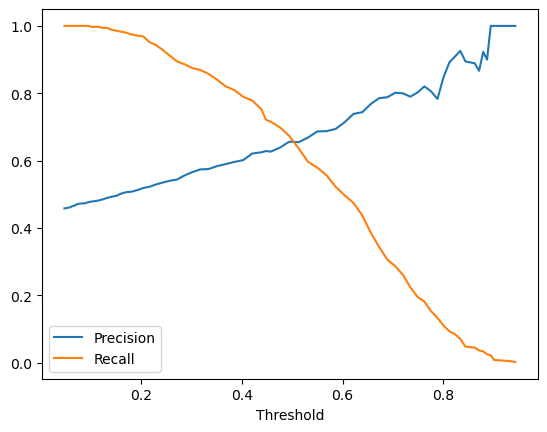

In [68]:
plt.plot(threshold,precision[:-1],label="Precision")
plt.plot(threshold,recall[:-1],label="Recall")
plt.xlabel("Threshold")
plt.legend()

En el caso anterior (de manera muy similar como teniamos el problema de varianza sesgo) vemos que al incrementar la precision (minimizamos falsos positivos), baja el recall( incrementan falsos negativos). Si aumenta el recall (bajan los falsos negativos) baja la precision (suben falsos positivos)

<img src="tradeoffprecisionrecall.png">

<src img ="tradeoffprecisionrecall.png">


¿Qué metricas usar?

* Usamos *precision* si no te interesa maximizar la *pureza* de nuestras predicciones a cambio de sacrificar el número de predicciones hechas como verdaderos. Es decir, menor $FP$ a camio de màs $FN$. En otras palabras, al sacrificar el número de prediciones hechas como verdadera, cometes menor error $FP$ pero te llevas más error $FN$. Sacrificar verdaderos al pedirle un umbral más alto. 

* Usamos el *recall* si nos interesa maximizar el número de observaciones positivas clasificadas como positivas a costa de clasificar incorrectamente observaciones negativas como positivas. Es decir, que cometamos más errores $FP$ a cambio de menos errores $FN$

### Alternativa a funcion en sklearn

In [69]:
from statsmodels.discrete.discrete_model import Logit
from statsmodels.tools.tools import add_constant

In [70]:
model0 = Logit(y_train,add_constant(x_train))
model0.fit().summary()

Optimization terminated successfully.
         Current function value: 0.582646
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               severity   No. Observations:                  768
Model:                          Logit   Df Residuals:                      766
Method:                           MLE   Df Model:                            1
Date:                Thu, 18 Jan 2024   Pseudo R-squ.:                  0.1552
Time:                        18:35:28   Log-Likelihood:                -447.47
converged:                       True   LL-Null:                       -529.67
Covariance Type:            nonrobust   LLR p-value:                 1.243e-37
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.3312      0.388    -11.156      0.000      -5.092      -3.570
x1             0.0743      0.007     11.113      0.000       0.061       0.087
==============================================================================
"""

In [71]:
# esta alternatica es util para ver el pvalue de la prueba t para cada uno de las covariables y ver que tan significativas son en el modelo

### Mejoremos el modelo con el resto de variables

In [8]:
datalink="http://archive.ics.uci.edu/ml/machine-learning-databases/mammographic-masses/mammographic_masses.data"
df=pd.read_csv(StringIO(requests.get(datalink).text),na_values="?",header=None)
df.columns=["bi_rads","age","shape","margin","density","severity"]
df=df.drop(columns="bi_rads")

In [9]:
df["age"] = df["age"].fillna(df["age"].mean())
df["shape"] = df["shape"].fillna(4)
df["margin"] = df["margin"].fillna(1)
df["density"] = df["density"].fillna(3)

In [10]:
print(df[df.severity==1].shape)
print(df[df.severity==0].shape)
### los datos están practicamente balanceados, se tienen casi la misma cantidad de obervaciones para cada etiqueta

(445, 5)
(516, 5)


### convertimos a variables dummies

Una variable dummy (también conocida como variable indicadora o variable ficticia) es una variable binaria que se utiliza para representar categorías distintas en un modelo de regresión o análisis estadístico. Se asigna el valor 0 o 1 a cada observación según si pertenece o no a una categoría específica. Al proceso de transformar las variables categoricas  a variables dummy se le llama "one hot encoding". Usualmente si tenemos n categorias , podemos crear n-1 variables dummy, ya que crear n variables puede llevar a problemas de multicolinealidad

In [11]:
### convertimos a variables dummies
dummies_shape=pd.get_dummies(df["shape"],prefix="shape",drop_first=True).replace(True,1).replace(False,0)
dummies_margin=pd.get_dummies(df["margin"],prefix="margin",drop_first=True).replace(True,1).replace(False,0)
dummies_density=pd.get_dummies(df["density"],prefix="density",drop_first=True).replace(True,1).replace(False,0)

In [12]:
df = pd.concat([df,dummies_shape,dummies_margin,dummies_density],axis=1)
df

,age,shape,margin,density,severity,shape_2.0,shape_3.0,shape_4.0,margin_2.0,margin_3.0,margin_4.0,margin_5.0,density_2.0,density_3.0,density_4.0
0,67.0,3.0,5.0,3.0,1,0,1,0,0,0,0,1,0,1,0
1,43.0,1.0,1.0,3.0,1,0,0,0,0,0,0,0,0,1,0
2,58.0,4.0,5.0,3.0,1,0,0,1,0,0,0,1,0,1,0
3,28.0,1.0,1.0,3.0,0,0,0,0,0,0,0,0,0,1,0
4,74.0,1.0,5.0,3.0,1,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
956,47.0,2.0,1.0,3.0,0,1,0,0,0,0,0,0,0,1,0
957,56.0,4.0,5.0,3.0,1,0,0,1,0,0,0,1,0,1,0
958,64.0,4.0,5.0,3.0,0,0,0,1,0,0,0,1,0,1,0
959,66.0,4.0,5.0,3.0,1,0,0,1,0,0,0,1,0,1,0


eliminamos las variables originales

In [13]:
df=df.drop(columns=["shape","margin","density"])

In [14]:
df

,age,severity,shape_2.0,shape_3.0,shape_4.0,margin_2.0,margin_3.0,margin_4.0,margin_5.0,density_2.0,density_3.0,density_4.0
0,67.0,1,0,1,0,0,0,0,1,0,1,0
1,43.0,1,0,0,0,0,0,0,0,0,1,0
2,58.0,1,0,0,1,0,0,0,1,0,1,0
3,28.0,0,0,0,0,0,0,0,0,0,1,0
4,74.0,1,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
956,47.0,0,1,0,0,0,0,0,0,0,1,0
957,56.0,1,0,0,1,0,0,0,1,0,1,0
958,64.0,0,0,0,1,0,0,0,1,0,1,0
959,66.0,1,0,0,1,0,0,0,1,0,1,0


In [15]:
X=df.drop(columns="severity")
Y=df["severity"]

In [16]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.3, random_state=3) # 70% en conjunto de train

In [92]:
### el parametro max_iter especifica el numero de iteraciones que hará el algoritmo del descenso del gradiente
log_reg= c(max_iter=1000).fit(X_train,Y_train)
y_pred = log_reg.predict(X_test)
print("accuracy en train,",log_reg.score(X_train,Y_train))
print("accuracy en test,",log_reg.score(X_test,Y_test)) 
# tenemos buenos accuracys en ambos conjuntos y no vemos evidencia de overfitting

accuracy en train, 0.8005952380952381
accuracy en test, 0.7993079584775087


In [93]:
cvscore=cross_validate(log_reg,X_train,Y_train,cv=5,scoring="accuracy")
cvscore ## hacemos validacion cruzada

{'fit_time': array([0.05418134, 0.06169057, 0.04428601, 0.05117917, 0.0488925 ]),
 'score_time': array([0.00360537, 0.00262618, 0.01562834, 0.00382113, 0.01481462]),
 'test_score': array([0.78518519, 0.8       , 0.82089552, 0.80597015, 0.7761194 ])}

In [94]:
cvscore["test_score"].mean() # buen resultado en validacion cruzada

0.7976340519624102

<Axes: >

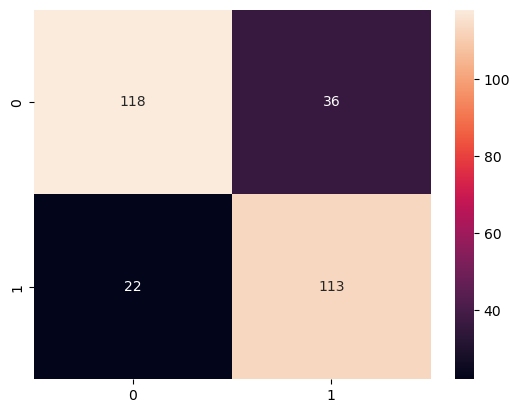

In [95]:
cmat=confusion_matrix(Y_test,y_pred)
sns.heatmap(cmat,annot=True,fmt=",")
### X predicciones, Y reales

In [96]:
### las metricas mejoran

In [97]:
print(f"precision:{precision_score(Y_test,y_pred):0.2%}")
print(f"recall:{recall_score(Y_test,y_pred):0.2%}")
print(f"f1:{f1_score(Y_test,y_pred):0.2%}")

precision:75.84%
recall:83.70%
f1:79.58%


In [98]:
probs=log_reg.predict_proba(X_test)[:,1]

Text(0.5, 1.0, 'ROC CURVE')

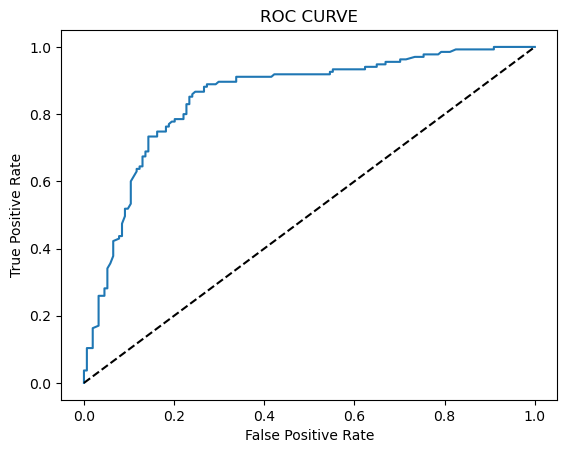

In [99]:
# graficamos la curva roc
fpr,tpr,threshold=roc_curve(Y_test,probs)
plt.plot(fpr,tpr)
plt.plot(fpr,fpr,linestyle="--",color="k")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC CURVE")

In [100]:
AUROC=roc_auc_score(Y_test,probs)
AUROC #### probabilidad de el que el modelo distinga entre clase positiva y clase negativa

0.8505531505531505

In [101]:
### aumentamos el area bajo la curva 10 puntos

con los valores definidos tenemos un buen clasificador con el area de .85

calculamos el estadistico de Jouden

In [102]:
J=tpr-fpr
ix=np.argmax(J)
best_threshold=threshold[ix]
best_threshold

0.46613335358769203

In [103]:
### ajustamos el umbral con el valor  del estadistico de Jouden


In [104]:
### si la probabilidad es mayor que 0.46613335358769203 entonces clasificamos como 1
probs_jouden = [i[1] for i in log_reg.predict_proba(X_test)]
predict_jouden = np.where(probs_jouden > best_threshold, 1, 0)

<Axes: >

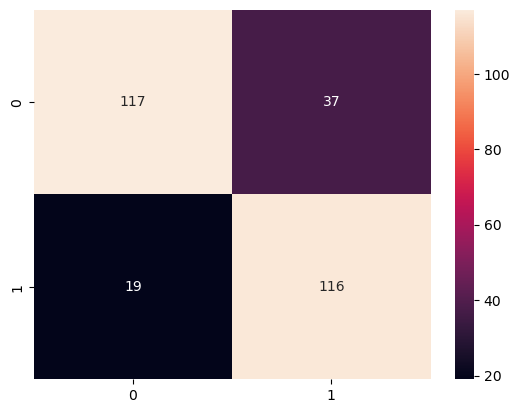

In [105]:
cmat_jouden=confusion_matrix(Y_test,predict_jouden)
sns.heatmap(cmat_jouden,annot=True,fmt=",")
### X predicciones, Y reales

In [106]:
print(f"accuracy:{accuracy_score(Y_test,predict_jouden):0.2%}")
print(f"precision:{precision_score(Y_test,predict_jouden):0.2%}")
print(f"recall:{recall_score(Y_test,predict_jouden):0.2%}")
print(f"f1:{f1_score(Y_test,predict_jouden):0.2%}")

accuracy:80.62%
precision:75.82%
recall:85.93%
f1:80.56%


### gridsearch con lasso y ridge 

vamos a intentar maximizar el accuracy

In [107]:
model_params={
    "reg_log":{
        "model":LogisticRegression(), 
        "params":{
            "penalty":["l1","l2","elasticnet"], # tipo de regularización
            "max_iter":[100,1000,10000], # numero de iteraciones en algoritmo de optimizacion
            "C":[.0001,.001,.01,.1,1,10,100], ### es lo equivalente a alpha pero inverso (mas chico implica mayor penalización)
            "solver":["lbfgs", "liblinear", "newton-cg", "newton-cholesky", "sag", "saga"] ### algoritmos de optimizacion (para mas detalle ver la doc de SKLEARN)
        }
    }
            
}

In [108]:
accuracy_models=[] # lista para guardar el accuracy de cada uno de los modelos
for model_name,mp in model_params.items():

    modelo=GridSearchCV(mp["model"],mp["params"],cv=5,n_jobs=-1,scoring="accuracy",verbose=0) #evaluamos con accuracy y partimos en 3 el conjunto de train
    
    modelo.fit(X_train,Y_train)
    accuracy_models.append({
        "model":model_name,
        "best_score":modelo.best_score_,
        "best_params":modelo.best_params_
    })

C:\Users\Sergio.Chavez\AppData\Local\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:378: FitFailedWarning: 
1050 fits failed out of a total of 1890.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
105 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Sergio.Chavez\AppData\Local\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Sergio.Chavez\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1162, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  Fi

In [109]:
### resumimos en una tabla los resultados obtenidos en gridsearch. se muestra el mejor modelo con un accuracy promedio de .80
df_accuracy_models=pd.DataFrame(accuracy_models).sort_values(by="best_score",ascending=False)
df_accuracy_models

,model,best_score,best_params
0,reg_log,0.802112,"{'C': 0.1, 'max_iter': 100, 'penalty': 'l2', '..."


In [110]:
df_accuracy_models.best_params.values

array([{'C': 0.1, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}],
      dtype=object)

ajustamos el anterior modelo

In [111]:
log_reg_accuracy= LogisticRegression(C=0.1,max_iter=100,penalty="l2",solver="liblinear").fit(X_train,Y_train)
y_pred = log_reg_accuracy.predict(X_test)
print("accuracy en train,",log_reg_accuracy.score(X_train,Y_train))
print("accuracy en test,",log_reg_accuracy.score(X_test,Y_test)) 
# tenemos buenos accuracys en ambos conjuntos y no vemos evidencia de overfitting

accuracy en train, 0.8080357142857143
accuracy en test, 0.7820069204152249


<Axes: >

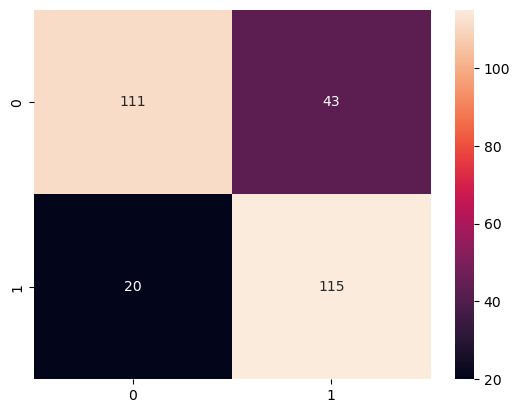

In [112]:
cmat_accuracy=confusion_matrix(Y_test,y_pred)
sns.heatmap(cmat_accuracy,annot=True,fmt=",")
### X predicciones, Y reales

In [113]:
cvscore=cross_validate(log_reg,X_train,Y_train,cv=5,scoring="accuracy")
cvscore["test_score"].mean() # hacemos validación cruzada y vemos un buen resultado

0.7976340519624102

In [114]:
cvscore=cross_validate(log_reg_accuracy,X_train,Y_train,cv=5,scoring="accuracy")
cvscore["test_score"].mean()

0.8021116639027086

In [115]:
### mejor accuracy en validación cruzada (Será mejor estimador para datos nuevos)

### DOCUMENTACION Y MODELO COMO ARCHIVO PICKLE

Podemos utilizar el modulo Pickle para guardar nuestro modelo ya entrenado y solamente importar al momento de querer hacer predicciones

In [2]:
import pickle

In [117]:
### la sintaxis para guardar el modelo es la siguiente
filename = 'regresionlogistica_tumores.sav'
pickle.dump(log_reg_accuracy, open(filename, 'wb'))

In [4]:
### la sintaxis para cargar el modelo es la siguiente
filename = 'regresionlogistica_tumores.sav'
loaded_model = pickle.load(open(filename, 'rb'))

con el archivo llamado "regresionlogistica_tumores.sav" podemos importar nuestro modelo ya entrenado en cualquier momento y listo para hacer predicciones. Al momento de querer hacer nuevas predicciones tendremos que ingresar valores para las mismas variables con las que entrenamos al modelo, para esto guardamos un archivo con todas las variables que utilizamos en su entrenamiento

In [119]:
pd.DataFrame(X_train.columns.tolist(),columns=["variables predictoras"]).to_csv("variables_regresionlogistica_tumores.csv",index=False)

In [ ]:
#### usamos el modelo para hacer nuevas predicciones

In [20]:
loaded_model.predict([[56,0
,1
,0
,0
,0
,1
,0
,0
,1
,0
]])

C:\Users\schav\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1], dtype=int64)

In [26]:
loaded_model.predict([[1,
0,
0,
1,
1,
0,
0,
0,
1,
30,
0
]])

C:\Users\schav\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1], dtype=int64)